In [1]:
import importlib
import scipy
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os


import iMSM.extensions.npc.npc
importlib.reload(iMSM.extensions.npc.npc)
from iMSM.extensions.npc.npc import run

import iMSM.extensions.npc.npc_utils
importlib.reload(iMSM.extensions.npc.npc_utils)
from iMSM.extensions.npc.npc_utils import radius_a_to_kda, amount_to_concentration

import iMSM.extensions.npc.npc_graph_figure
importlib.reload(iMSM.extensions.npc.npc_graph_figure)
from iMSM.extensions.npc.npc_graph_figure import estimate_cluters_mu_cov, calc_coordinate_edges_dict, get_sorted_anchor_coordinates_np

In [10]:
pore_diameter_nm = 46
for sites in [2,4,6]:
    for radius in [10, 14, 18, 22, 26]:
        print (f"~~~~~~~ Running for {sites} sites and radius {radius} ~~~~~~~")
        for subset in [1.0]: #             
            checkpoint_path = f"data/ntr_variants_{pore_diameter_nm}R/{sites}_{radius}/"
            params = {}
            params['LOAD_MD_KAP_SITES'] = sites
            params['LOAD_MD_KAP_RADIUS'] = radius
            params['LOAD_MD_KAP_AMOUNT'] = 100
            params['LOAD_MD_BASE_PATH'] = f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants_{pore_diameter_nm}R/{sites}_sites_small"
            params['LOAD_MD_SIMS_RANGE'] = range(1, 31)
            params['LOAD_MD_START_TIME_NS'] = 10000
            params['LOAD_MD_END_TIME_NS'] = 30000
            params['LOAD_MD_STEP_NS'] = 100
            params['CUSTOM_FG_COORDS_PATH'] = f"data/ntr_variants_{pore_diameter_nm}R/{sites}_{10}/2_single_sim_fg_coords/"
            params['TM_PRIOR'] = 0.0001
            params['DISTANCE_STATE_THRESHOLD_NM'] = 10
            params['WINDOW_SIZE_STEPS'] = 50
            params['SOFT_SCALE_NM'] = None
            
            params['MODE'] = "subset"
            params['DATA_SUBSET'] = subset
            params['DATA_SUBSET_INDEX'] = 0
            params['DATA_SUBSET_MODE'] = "time" 
            
            params['PRUNE_THRESH'] = 0.95
            # params['USE_PCCA'] = True
            # params['PCCA_MACROSTATES'] = 5
            params['REVERSIBLE_MSM'] = False

            params['STATE_CHOICE_METHOD'] = "distance_clustering_z" 
            params['CLUSTERING_Z_STRENGTH'] = np.sqrt(458) / 10
            params['N_CLUSTERS'] = [320]
            
            run(checkpoint_path, params_override=params, start_stage=5, end_stage=8)

~~~~~~~ Running for 2 sites and radius 10 ~~~~~~~
Running stage 5...
Reduced from 320 to 50 clusters after merging heavy nuc/cys centroids (nuc merged: 143, cys merged: 127)
Reduced from 50 to 50 clusters after pruning underpopulated centroids
Stage 5 completed.
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 320 clusters: 274.12913211856215 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ Running for 2 sites and radius 14 ~~~~~~~
Running stage 5...
Reduced from 320 to 42 clusters after merging heavy nuc/cys centroids (nuc merged: 127, cys merged: 151)
Reduced from 42 to 42 clusters after pruning underpopulated centroids
Stage 5 completed.
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 320 clusters: 55.6850494083072 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ Running for 2 sites and radius 18 ~~~~~~~
Running stage 5...
Reduced from 320 to 34 clusters after merging heavy nuc/cys centroids (nuc merged: 167, c

In [ ]:
# Executes the pipeline for 6 sites and a 26 A radius and 46 diameter to compare 
# timescales across different window sizes

for sites in [6]:
    for radius in [26]:
        print (f"~~~~~~~ Running for {sites} sites and radius {radius} ~~~~~~~")
        # for subset in [1]: # 
        for window_size_steps in [5, 10, 25, 50, 100]: 
            print (f"~~~~~~~ window size {window_size_steps} steps ~~~~~~~")
            subset = 1
            
            checkpoint_path = f"data/ntr_variants_6_26_46R_timescales/window_{window_size_steps}_steps/"
            
            params = {}
            params['LOAD_MD_KAP_SITES'] = sites
            params['LOAD_MD_KAP_RADIUS'] = radius
            params['LOAD_MD_KAP_AMOUNT'] = 100
            params['LOAD_MD_BASE_PATH'] = f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants_46R/{sites}_sites_small"
            params['LOAD_MD_SIMS_RANGE'] = range(1, 31)
            params['LOAD_MD_START_TIME_NS'] = 10000
            params['LOAD_MD_END_TIME_NS'] = 30000
            params['LOAD_MD_STEP_NS'] = 100
            params['CUSTOM_FG_COORDS_PATH'] = f"data/ntr_variants_46R/{sites}_{10}/2_single_sim_fg_coords/"
            params['CUSTOM_CATEGORIZED_PATH'] = f"data/ntr_variants_46R/{sites}_{radius}/3_categorized.pickle"
            params['TM_PRIOR'] = 0.0001
            params['DISTANCE_STATE_THRESHOLD_NM'] = 10
            params['WINDOW_SIZE_STEPS'] = window_size_steps
            params['SOFT_SCALE_NM'] = None
            params['SAVE_CLUSTER_3D_LOCATIONS'] = False
            params['MODE'] = "subset"
            params['N_CLUSTERS'] = [160]
            params['DATA_SUBSET'] = subset
            params['DATA_SUBSET_INDEX'] = 0
            params['DATA_SUBSET_MODE'] = "time" 
            params['STATE_CHOICE_METHOD'] = "distance" 


            
            
            run(checkpoint_path, params_override=params, start_stage=5, end_stage=7)
            

In [2]:
# run for 62 diameter

pore_diameter_nm = 62
for sites in [6,4,2]:
    for radius in [10, 14, 18, 22, 26]:
        print (f"~~~~~~~ Running for {sites} sites and radius {radius} ~~~~~~~")
        for subset in [1.0]: #             
            checkpoint_path = f"data/ntr_variants_{pore_diameter_nm}R/{sites}_{radius}/"
            params = {}
            params['LOAD_MD_KAP_SITES'] = sites
            params['LOAD_MD_KAP_RADIUS'] = radius
            params['LOAD_MD_KAP_AMOUNT'] = 100
            params['LOAD_MD_BASE_PATH'] = f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants_{pore_diameter_nm}R/{sites}_sites_small"
            params['LOAD_MD_SIMS_RANGE'] = range(1, 31)
            params['LOAD_MD_START_TIME_NS'] = 10000
            params['LOAD_MD_END_TIME_NS'] = 30000
            params['LOAD_MD_STEP_NS'] = 100
            params['CUSTOM_FG_COORDS_PATH'] = f"data/ntr_variants_{pore_diameter_nm}R/{sites}_{10}/2_single_sim_fg_coords/"
            params['TM_PRIOR'] = 0.0001
            # params['STATE_CHOICE_METHOD'] = "distance" # options: "prominent", "distance", "nuc_cyt_treshold"
            params['DISTANCE_STATE_THRESHOLD_NM'] = 10
            params['WINDOW_SIZE_STEPS'] = 50
            params['SOFT_SCALE_NM'] = None
            
            params['MODE'] = "subset"
            params['DATA_SUBSET'] = subset
            params['DATA_SUBSET_INDEX'] = 0
            params['DATA_SUBSET_MODE'] = "time" 
            
            params['PRUNE_THRESH'] = 0.95
            # params['USE_PCCA'] = True
            # params['PCCA_MACROSTATES'] = 5
            params['REVERSIBLE_MSM'] = False

            params['STATE_CHOICE_METHOD'] = "distance_clustering_z" 
            params['CLUSTERING_Z_STRENGTH'] = np.sqrt(458) / 10
            params['N_CLUSTERS'] = [320]
            
            run(checkpoint_path, params_override=params, start_stage=5, end_stage=8)

In [2]:
# run for 70 diameter
pore_diameter_nm = 70
for sites in [2]:
    for radius in [10, 14, 18, 22, 26]:
        print (f"~~~~~~~ Running for {sites} sites and radius {radius} ~~~~~~~")
        for subset in [1.0]: #             
            checkpoint_path = f"data/ntr_variants_{pore_diameter_nm}R/{sites}_{radius}/"
            params = {}
            params['LOAD_MD_KAP_SITES'] = sites
            params['LOAD_MD_KAP_RADIUS'] = radius
            params['LOAD_MD_KAP_AMOUNT'] = 100
            params['LOAD_MD_BASE_PATH'] = f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants_{pore_diameter_nm}R/{sites}_sites_small"
            params['LOAD_MD_SIMS_RANGE'] = range(1, 31)
            params['LOAD_MD_START_TIME_NS'] = 10000
            params['LOAD_MD_END_TIME_NS'] = 30000
            params['LOAD_MD_STEP_NS'] = 100
            params['CUSTOM_FG_COORDS_PATH'] = f"data/ntr_variants_{pore_diameter_nm}R/{sites}_{10}/2_single_sim_fg_coords/"
            params['TM_PRIOR'] = 0.0001
            # params['STATE_CHOICE_METHOD'] = "distance" # options: "prominent", "distance", "nuc_cyt_treshold"
            params['DISTANCE_STATE_THRESHOLD_NM'] = 10
            params['WINDOW_SIZE_STEPS'] = 50
            params['SOFT_SCALE_NM'] = None
            
            params['MODE'] = "subset"
            params['DATA_SUBSET'] = subset
            params['DATA_SUBSET_INDEX'] = 0
            params['DATA_SUBSET_MODE'] = "time" 
            
            params['PRUNE_THRESH'] = 0.95
            # params['USE_PCCA'] = True
            # params['PCCA_MACROSTATES'] = 5
            params['REVERSIBLE_MSM'] = False

            params['STATE_CHOICE_METHOD'] = "distance_clustering_z" 
            params['CLUSTERING_Z_STRENGTH'] = np.sqrt(458) / 10
            params['N_CLUSTERS'] = [320]

            if sites == 2:
                params['IGNORED_SIMULATIONS'] = [1, 2, 3, 4, 21, 22]
            
            run(checkpoint_path, params_override=params, start_stage=3, end_stage=8)

~~~~~~~ Running for 2 sites and radius 10 ~~~~~~~
Running stage 3...
Using 16 cores
10-30, 5 10-30, 6 10-30, 7 10-30, 8 10-30, 9 10-30, 10 10-30, 11 10-30, 12 10-30, 13 10-30, 14 10-30, 15 10-30, 16 10-30, 17 10-30, 18 10-30, 19 10-30, 20 10-30, 23 10-30, 24 10-30, 25 10-30, 26 10-30, 27 10-30, 28 10-30, 29 10-30, 30 
Stage 3 completed.
Running stage 4...
Stage 4 completed.
Running stage 5...
Reduced from 320 to 98 clusters after merging heavy nuc/cys centroids (nuc merged: 111, cys merged: 111)
Reduced from 98 to 98 clusters after pruning underpopulated centroids
Stage 5 completed.
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 320 clusters: 1319.7911710261249 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ Running for 2 sites and radius 14 ~~~~~~~
Running stage 3...
Using 16 cores
10-30, 5 10-30, 6 10-30, 7 10-30, 8 10-30, 9 10-30, 10 10-30, 11 10-30, 12 10-30, 13 10-30, 14 10-30, 15 10-30, 16 10-30, 17 10-30, 18 10-30, 19 10-30, 20 10-30, 23 10

In [3]:
def poisson_confidence_interval(count, alpha=0.05):
    lower = scipy.stats.chi2.ppf(alpha/2, 2*count) / 2
    upper = scipy.stats.chi2.ppf(1-alpha/2, 2*(count+1)) / 2
    
    return lower, upper

# Collect data
def collect_perms_md(n_sites=None, radii=None, shorten_time_to=None):
    results = []
    for sites in n_sites:
        for radius in radii:
            for tunnel_diameter_nm in [46, 54, 62, 70]:
                if tunnel_diameter_nm == 54:
                    kap_coords_folder = f"data/ntr_variants/{sites}_{radius}_more/1_single_sim_kap_coords/"
                    n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability = collect_perms_md_single_type(kap_coords_folder, n_sims=30, start_time=10, end_time=70, shorten_time_to=shorten_time_to)
                else:
                    kap_coords_folder = f"data/ntr_variants_{tunnel_diameter_nm}R/{sites}_{radius}/1_single_sim_kap_coords/"
                    n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability = collect_perms_md_single_type(kap_coords_folder, n_sims=30, start_time=10, end_time=30, shorten_time_to=shorten_time_to)
                
                results.append({
                    'sites': sites,
                    'radius': radius,
                    'kda': radius_a_to_kda(radius),
                    'tunnel_diameter_nm': tunnel_diameter_nm,
                    'total_transports': total_full_transports,
                    'n_trajs': n_trajs,
                    'permeability': permeability,
                    'lower_permeability': lower_permeability if lower_permeability >=0 else 0,
                    'upper_permeability': upper_permeability if upper_permeability >=0 else 0
                })
    return results

def collect_perms_md_single_type(kap_coords_folder, n_sims, start_time, end_time, shorten_time_to, step_ns=100):
    """
    Count transport events from raw 3D kap coordinates.
    
    kap_coords_folder: path containing subfolders 1, 2, ..., n_sims,
                       each with a file 'start_time-end_time.pickle' of shape (kap_amount, 3, n_frames).
    step_ns: time per frame in nanoseconds (default 100 ns).
    """
    # Load and concatenate raw 3D coordinates across all simulations
    all_coords = []
    for sim_idx in range(1, n_sims + 1):
        path = os.path.join(kap_coords_folder, str(sim_idx), f"{start_time}-{end_time}.pickle")
        if not os.path.exists(path):
            print(f"File not found: {path}")
            continue
        with open(path, "rb") as f:
            coords = pickle.load(f)  # shape: (kap_amount, 3, n_frames)
        all_coords.append(coords)

    if not all_coords:
        return 0, 0, 0, 0, 0

    all_coords = np.concatenate(all_coords, axis=0)  # shape: (kap_amount * n_sims, 3, n_frames)

    _, _, n_frames = all_coords.shape
    time_us = n_frames * step_ns / 1000  # convert ns → µs

    if shorten_time_to is not None:
        if shorten_time_to > time_us:
            # raise ValueError(f"shorten_time_to {shorten_time_to} µs is greater than trajectory length {time_us} µs")
            n_frames_to_use = n_frames
            time_us = time_us
        else:
            n_frames_to_use = int(shorten_time_to * 1000 / step_ns)
            time_us = shorten_time_to
        all_coords = all_coords[:, :, :n_frames_to_use]

    # Count transport events across all kap trajectories
    # z-axis is index 2 in the (kap_amount, 3, n_frames) array
    total_full_transports = 0
    n_trajs = all_coords.shape[0]
    for i in range(n_trajs):
        z = all_coords[i, 2, :]  # shape: (n_frames,)
        last_side = None

        for z_val in z:
            if z_val >= 10:
                current_side = 1   # cytoplasmic side (top)
            elif z_val <= -10:
                current_side = 0   # nuclear side (bottom)
            else:
                continue           # inside the channel, not yet committed

            if last_side is None:
                last_side = current_side   # initialise, don't count
            elif last_side != current_side:
                total_full_transports += 1
                last_side = current_side

    concentration_M = amount_to_concentration(100, box_side_a=800)
    concentration_uM = concentration_M * 1e6
            
    time_s = time_us * 1e-6

    lower, upper = poisson_confidence_interval(total_full_transports)
    rate = total_full_transports / (time_s * n_sims)
    lower_rate = lower / (time_s * n_sims)
    upper_rate = upper / (time_s * n_sims)
    permeability = rate / concentration_uM
    lower_permeability = lower_rate / concentration_uM
    upper_permeability = upper_rate / concentration_uM
    return n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability

def collect_perms_msm(n_clusters=160):
    results = []
    for sites in n_sites:
        for radius in radii:
            for tunnel_diameter_nm in [46, 54, 62, 70]:
                path = None
                if tunnel_diameter_nm == 54:
                    path = f"data/ntr_variants/{sites}_{radius}_more/7_permeabilities_subsets/1.00fraction_simulations/0index/7_permeabilities.pickle"
                else:
                    path = f"data/ntr_variants_{tunnel_diameter_nm}R/{sites}_{radius}/7_permeabilities_subsets/1.00fraction/0index/7_permeabilities.pickle"
                
                if path and os.path.exists(path):
                    with open(path, "rb") as f:
                        perms_dict = pickle.load(f)
                    permeability = perms_dict[n_clusters]
                    results.append({
                        'sites': sites,
                        'radius': radius,
                        'kda': radius_a_to_kda(radius),
                        'tunnel_diameter_nm': tunnel_diameter_nm,
                        'permeability': permeability
                    })
    return results


n_sites = [2,4,6]
radii = [10, 14, 18, 22, 26]
md_results = collect_perms_md(n_sites=n_sites, radii=radii, shorten_time_to=20)
print(md_results)
msm_results = collect_perms_msm(n_clusters=320)
print(msm_results)

[{'sites': 2, 'radius': 10, 'kda': 3.47830926343323, 'tunnel_diameter_nm': 46, 'total_transports': 48, 'n_trajs': 3000, 'permeability': 246.66688552960002, 'lower_permeability': 181.87268921514976, 'upper_permeability': 327.0445038942067}, {'sites': 2, 'radius': 10, 'kda': 3.47830926343323, 'tunnel_diameter_nm': 54, 'total_transports': 197, 'n_trajs': 3000, 'permeability': 1012.362009361067, 'lower_permeability': 875.9225407648679, 'upper_permeability': 1164.0299634798173}, {'sites': 2, 'radius': 10, 'kda': 3.47830926343323, 'tunnel_diameter_nm': 62, 'total_transports': 375, 'n_trajs': 3000, 'permeability': 1927.0850432000002, 'lower_permeability': 1736.9527028337043, 'upper_permeability': 2132.3489939588358}, {'sites': 2, 'radius': 10, 'kda': 3.47830926343323, 'tunnel_diameter_nm': 70, 'total_transports': 444, 'n_trajs': 3000, 'permeability': 2281.668691148801, 'lower_permeability': 2074.345959518175, 'upper_permeability': 2504.102288169584}, {'sites': 2, 'radius': 14, 'kda': 9.544480

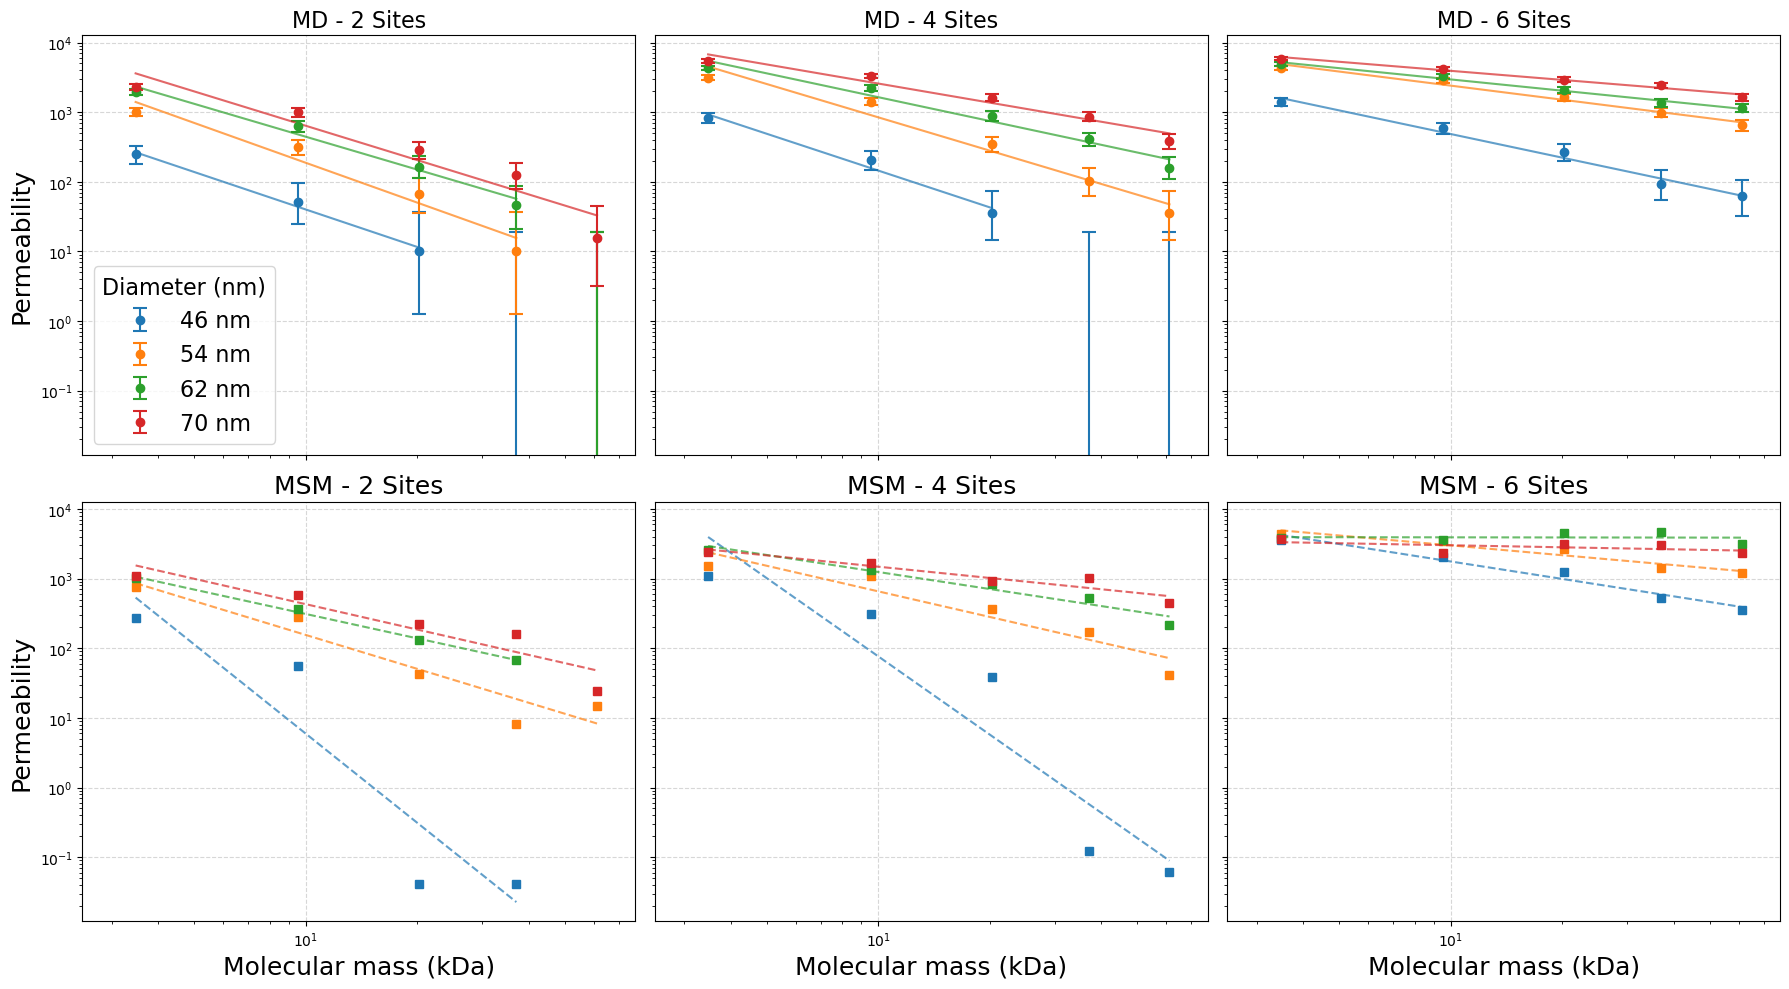

In [5]:
def weighted_power_law_fit(x, y, y_err=None):
    weights = None
    if y_err is not None:
        log_y_err = y_err / y
        weights = 1 / (log_y_err ** 2)
        weights = np.nan_to_num(weights, nan=1.0, posinf=1.0, neginf=1.0)
        weights = weights / np.mean(weights)
        weights = np.clip(weights, 0.1, 10)

    coeffs = np.polyfit(np.log10(x), np.log10(y), deg=1, w=weights)
    poly = np.poly1d(coeffs)
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = 10 ** poly(np.log10(x_fit))
    y_fit_per_original_x = 10 ** poly(np.log10(x))
    slope, intercept = coeffs
    return x_fit, y_fit, slope, intercept, y_fit_per_original_x

# Convert the results list of dicts to Pandas DataFrames
df_md = pd.DataFrame(md_results)
df_msm = pd.DataFrame(msm_results)

# Create a figure with 2 rows (MD, MSM) and 3 columns (Sites)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True, sharex=True)

# Get the unique site values (should be [2, 4, 6])
n_sites_list = sorted(df_md['sites'].unique())
diameters = sorted(df_md['tunnel_diameter_nm'].unique()) # [46, 54, 62]

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
diameter_colors = {d: color_cycle[i] for i, d in enumerate(diameters)}

for col_idx, sites in enumerate(n_sites_list):
    # Filter data for the current number of sites
    df_md_sites = df_md[df_md['sites'] == sites]
    df_msm_sites = df_msm[df_msm['sites'] == sites]
    
    # Row 0: MD Data
    ax_md = axes[0, col_idx]
    for diameter in diameters:
        color = diameter_colors[diameter]
        df_plot = df_md_sites[df_md_sites['tunnel_diameter_nm'] == diameter].sort_values('kda')
        if not df_plot.empty:
            x = df_plot['kda'].values
            y = df_plot['permeability'].values
            valid = y > 0
            invalid = y == 0
            
            # Plot valid points (greater than 0 transport events)
            if np.any(valid):
                x_v = x[valid]
                y_v = y[valid]
                yerr_l = np.maximum(0, y_v - df_plot['lower_permeability'].values[valid])
                yerr_u = np.maximum(0, df_plot['upper_permeability'].values[valid] - y_v)
                
                ax_md.errorbar(
                    x_v, y_v,
                    yerr=[yerr_l, yerr_u],
                    label=f'{diameter} nm',
                    marker='o',
                    capsize=5,
                    capthick=1.5,
                    elinewidth=1.5,
                    linestyle='none',
                    color=color
                )
                
                if len(x_v) >= 2:
                    x_fit, y_fit, _, _, _ = weighted_power_law_fit(x_v, y_v, y_err=None)
                    ax_md.plot(x_fit, y_fit, linestyle='-', color=color, alpha=0.7)

            # Plot invalid points (0 transport events) as upper limits
            if np.any(invalid):
                x_inv = x[invalid]
                y_inv = df_plot['upper_permeability'].values[invalid]
                # Label only if valid points weren't plotted for this diameter to avoid duplicate legend entries
                lbl = f'{diameter} nm' if not np.any(valid) else None
                ax_md.errorbar(
                    x_inv, y_inv,
                    yerr=[y_inv, np.zeros_like(y_inv)],  # Lower error goes to 0 (-inf on log), upper error is 0
                    label=lbl,
                    marker='none',                       # Use 'none' for a pure 'T' shape, or keep 'o' and fillstyle='none'
                    capsize=5,
                    capthick=1.5,
                    elinewidth=1.5,
                    linestyle='none',
                    color=color
                )


    ax_md.set_title(f'MD - {sites} Sites', fontsize=16)
    ax_md.set_xscale('log')
    ax_md.set_yscale('log')
    ax_md.grid(True, linestyle='--', alpha=0.5)
    if col_idx == 0:
        ax_md.set_ylabel('Permeability', fontsize=18)
        ax_md.legend(title='Diameter (nm)', loc='lower left', fontsize=16, title_fontsize=16)

    # Row 1: MSM Data
    ax_msm = axes[1, col_idx]
    for diameter in diameters:
        color = diameter_colors[diameter]
        df_msm_plot = df_msm_sites[df_msm_sites['tunnel_diameter_nm'] == diameter].sort_values('kda')
        if not df_msm_plot.empty:
            x_msm = df_msm_plot['kda'].values
            y_msm = df_msm_plot['permeability'].values
            valid_msm = y_msm > 0
            if np.any(valid_msm):
                x_mv = x_msm[valid_msm]
                y_mv = y_msm[valid_msm]

                ax_msm.plot(
                    x_mv, y_mv,
                    label=f'{diameter} nm',
                    marker='s',
                    linestyle='none',
                    color=color
                )
                
                if len(x_mv) >= 2:
                    x_fit_msm, y_fit_msm, _, _, _ = weighted_power_law_fit(x_mv, y_mv, y_err=None)
                    ax_msm.plot(x_fit_msm, y_fit_msm, linestyle='--', color=color, alpha=0.7)
            
    ax_msm.set_title(f'MSM - {sites} Sites', fontsize=18)
    ax_msm.set_xlabel('Molecular mass (kDa)', fontsize=18)
    ax_msm.set_xscale('log')
    ax_msm.set_yscale('log')
    ax_msm.grid(True, linestyle='--', alpha=0.5)
    if col_idx == 0:
        ax_msm.set_ylabel('Permeability', fontsize=18)
        # ax_msm.legend(title='Diameter (nm)', loc='lower left', fontsize=16)

# Adjust x-axis across all columns (since sharex=True, setting it on one affects all)
axes[0, 0].set_xlim(left=2.5)

plt.tight_layout()
plt.show()

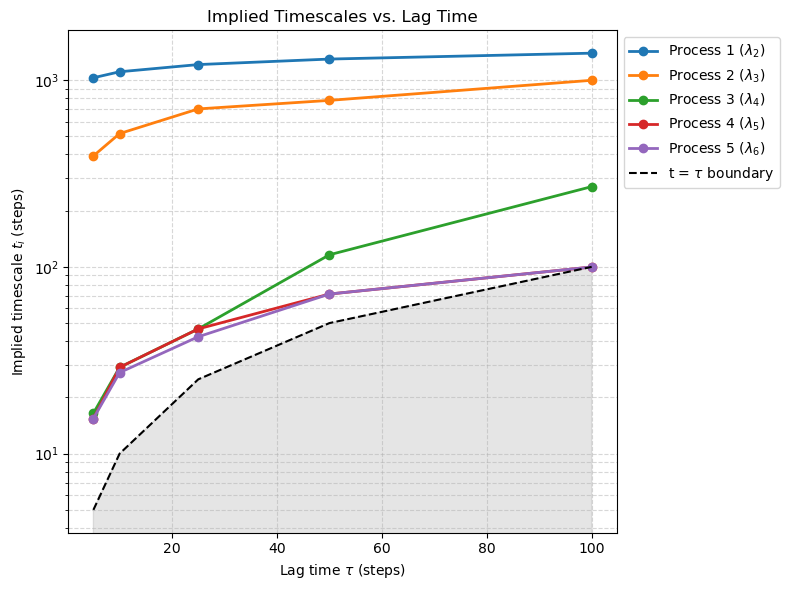

In [6]:
n_top_eigenvalues = 5

timescales = []
for i in range(n_top_eigenvalues):
    timescales.append([])
    
for window_size_steps in [5, 10, 25, 50, 100]: 
    with open(f"data/ntr_variants_6_26_46R_timescales/window_{window_size_steps}_steps/6_transition_matrices_subsets/1.00fraction/0index/160clusters.pickle", "rb") as f:
        tm = pickle.load(f)
        
    # 1. Compute the eigenvalues of the transition matrix
    eigenvalues = np.linalg.eigvals(tm)
    
    # 2. Sort the eigenvalues by absolute magnitude in descending order
    sorted_eigenvalues = np.sort(np.abs(eigenvalues))[::-1]
    
    # 3. Compute the implied timescales
    for i in range(n_top_eigenvalues):
        # We use i + 1 to skip the 0th eigenvalue (which is ~1.0 for the stationary distribution)
        lambda_i = sorted_eigenvalues[i + 1]
        
        # Catch numerical instability edge-cases (lambda should be strictly between 0 and 1)
        if lambda_i >= 1.0 or lambda_i <= 0.0:
            t_i = np.nan
        else:
            # Apply the formula: t_i = -tau / ln|lambda_i|
            t_i = -window_size_steps / np.log(lambda_i)
            
        timescales[i].append(t_i)
        
# Plotting
# The lag times used in your loop
lag_times = [5, 10, 25, 50, 100]

plt.figure(figsize=(8, 6))

# Plot each of the computed timescales
for i in range(n_top_eigenvalues):
    plt.plot(lag_times, timescales[i], marker='o', linewidth=2, label=f'Process {i+1} ($\lambda_{i+2}$)')

# Plot the t = tau boundary
plt.plot(lag_times, lag_times, color='black', linestyle='--', label='t = $\\tau$ boundary')
plt.fill_between(lag_times, 0, lag_times, color='grey', alpha=0.2)

# Standard ITS plots use a logarithmic y-axis
plt.yscale('log')

# Formatting
plt.xlabel('Lag time $\\tau$ (steps)')
plt.ylabel('Implied timescale $t_i$ (steps)')
plt.title('Implied Timescales vs. Lag Time')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()

# Display the plot
plt.show()